# Predicting a User's Next Payday
## XGBoost Quantile Regression, Cost-Aware Decisioning, and a Neural-Network Benchmark

This notebook is an **interview-ready machine-learning project** for a payroll MLE team whose goal is to estimate the next paycheck date and recover money owed without creating an avoidable negative customer experience.

The key business asymmetry is:

- **Predicting too early is expensive and harmful.** A debit can fail, create an overdraft, trigger support contacts, or damage trust.
- **Predicting slightly late is usually less harmful.** Recovery is delayed, but the user is less likely to be harmed.

Therefore, this is not merely a date-prediction problem. It is a **decision-under-uncertainty problem with asymmetric costs, operational constraints, and customer-protection guardrails**.

### What this notebook demonstrates

1. A realistic synthetic payroll and bank-account dataset.
2. Event-time-safe feature engineering.
3. Chronological train, validation, and test splits.
4. Strong schedule-based baselines.
5. XGBoost point regression for date accuracy.
6. XGBoost quantile regression for conservative collection timing.
7. Validation-based policy selection using asymmetric business cost.
8. A PyTorch neural network that predicts a probability distribution over future payday offsets.
9. Calibration, abstention, risk-versus-coverage analysis, and segment diagnostics.
10. Production architecture, monitoring, experimentation, and interview talking points.

> **Important:** All users, dates, balances, paychecks, and outcomes in this notebook are synthetic. The notebook is educational and is not a production debit policy. A real system must satisfy authorization, consumer-protection, banking, privacy, fairness, and model-governance requirements.

## 0. Business framing

### Prediction target

At a clearly defined **snapshot timestamp**, predict the first verified payroll deposit date after that timestamp.

The modeling target is:

$$
y_i = \text{days between snapshot time and next verified paycheck}
$$

A date is recovered as:

$$
\widehat{\text{next payday}} = \text{snapshot date} + \widehat y
$$

### Two outputs are useful

| Output | Purpose |
|---|---|
| Point estimate | Best estimate of the next payday; optimized for absolute date error |
| Upper quantile / probability distribution | Conservative decision date; optimized to reduce the probability of debiting before payroll arrives |

### Example asymmetric cost

For illustration, this project assumes:

- A debit before payday costs **$35** in expected failure, support, reimbursement, and trust impact.
- Waiting after payday costs **$0.75 per delayed day** in working-capital and recovery delay.

These values are placeholders. In production they should be estimated with Finance, Risk, Operations, Support, Legal, and experimentation data.

## 1. Environment

The notebook uses widely available Python packages. XGBoost is the primary model. PyTorch is optional but enabled in this executed version.

In [2]:
# Uncomment in a fresh environment.
# %pip install -q "numpy>=2.0" "pandas>=2.2" "scikit-learn>=1.5" \
#     "xgboost>=3.1,<4" "matplotlib>=3.8" "torch>=2.2" \
#     "scipy>=1.12" "joblib>=1.3" "nbformat>=5.9"

In [3]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import MonthEnd
from scipy.special import softmax
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "torch": torch.__version__ if TORCH_AVAILABLE else "not installed",
})

{'python': '3.12.5', 'numpy': '2.1.0', 'pandas': '2.2.2', 'scikit_learn': '1.8.0', 'xgboost': '3.3.0', 'torch': '2.7.0+cpu'}


## 2. Configuration and decision assumptions

The defaults keep the notebook fast enough for an interview demonstration while producing a useful amount of data.

In [4]:
N_SYNTHETIC_USERS = 30_000
MAX_HORIZON_DAYS = 45
RUN_NEURAL_NETWORK = TORCH_AVAILABLE

OUTPUT_DIR = Path("artifacts_next_payday")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Illustrative business costs, not production values.
EARLY_DEBIT_EVENT_COST = 35.00
LATE_RECOVERY_COST_PER_DAY = 0.75

# A second policy requirement: no more than 5% of validation decisions should
# occur before the actual paycheck date.
TARGET_MAX_EARLY_RATE = 0.05

data1 ={
    "synthetic_users": N_SYNTHETIC_USERS, 
    "max_horizon_days": MAX_HORIZON_DAYS,
    "run_neural_network": RUN_NEURAL_NETWORK,
    "early_debit_cost": EARLY_DEBIT_EVENT_COST,
    "late_cost_per_day": LATE_RECOVERY_COST_PER_DAY,
}

print("\n".join(f"{k}: {v}" for k, v in data1.items()))

synthetic_users: 30000
max_horizon_days: 45
run_neural_network: True
early_debit_cost: 35.0
late_cost_per_day: 0.75


## 3. Label definition and leakage rules

A production label should be the first transaction after the snapshot that is confidently classified as a payroll deposit. The label pipeline should exclude or separately model:

- Government benefits
- Tax refunds
- Peer-to-peer transfers
- Cash deposits
- Reimbursements
- Reversed or returned deposits
- Duplicate pending and posted transactions
- Employer changes that invalidate the previous schedule

### Prediction-time leakage checklist

Every feature must be available at the snapshot timestamp. Examples of invalid features include:

- The amount or posting status of the future paycheck
- A payroll transaction memo received after scoring
- A later bank balance
- A retry result from the collection being scheduled
- Aggregations whose window accidentally includes future records

The synthetic generator below follows the same principle: target-generation variables such as `true_schedule_for_analysis_only` are excluded from model features.

## 4. Synthetic data-generating process

The simulator creates users with weekly, biweekly, semimonthly, monthly, or irregular pay behavior. It includes:

- Historical paycheck intervals and amounts
- Employer changes and schedule instability
- Weekend and holiday timing effects
- Occasional bank-posting delays
- Account balance and amount owed
- Previous failed debits and overdrafts
- Calendar and account-tenure features
- Mild temporal drift beginning in 2025

The latent schedule is retained only for analysis and is never given to the model.

In [5]:
def infer_cadence(median_interval: np.ndarray, interval_std: np.ndarray) -> np.ndarray:
    """Infer a coarse cadence from historical intervals only."""
    return np.select(
        [
            interval_std > 5.5,
            median_interval <= 9,
            median_interval <= 16,
            median_interval <= 24,
        ],
        [
            "irregular",
            "weekly",
            "biweekly_or_semimonthly",
            "irregular",
        ],
        default="monthly",
    )


def generate_synthetic_payday_data(
    n_users: int = 30_000,
    random_state: int = 42,
) -> pd.DataFrame:
    """Create one leakage-safe prediction snapshot per synthetic user."""
    local_rng = np.random.default_rng(random_state)

    schedule_values = np.array(
        ["weekly", "biweekly", "semimonthly", "monthly", "irregular"]
    )
    true_schedule = local_rng.choice(
        schedule_values,
        size=n_users,
        p=[0.18, 0.48, 0.22, 0.09, 0.03],
    )

    nominal_interval = np.select(
        [
            true_schedule == "weekly",
            true_schedule == "biweekly",
            true_schedule == "semimonthly",
            true_schedule == "monthly",
        ],
        [7, 14, 15, 30],
        default=19,
    ).astype(float)

    snapshot_start = np.datetime64("2024-01-01")
    snapshot_span_days = 714
    snapshot_dates = pd.to_datetime(
        snapshot_start
        + local_rng.integers(0, snapshot_span_days, size=n_users).astype("timedelta64[D]")
    )

    # A mild future-period drift makes chronological validation more meaningful.
    recent_employer_change = (
        local_rng.random(n_users)
        < np.where(snapshot_dates >= pd.Timestamp("2025-01-01"), 0.10, 0.07)
    ).astype(int)

    schedule_stability = np.clip(
        local_rng.beta(7, 2, size=n_users) - 0.35 * recent_employer_change,
        0.05,
        0.99,
    )

    # Eight historical paycheck intervals.
    historical_intervals = np.zeros((n_users, 8), dtype=float)
    for index in range(8):
        interval_noise = np.where(
            true_schedule == "weekly",
            local_rng.normal(0, 0.25, n_users),
            np.where(
                true_schedule == "biweekly",
                local_rng.normal(0, 0.45, n_users),
                np.where(
                    true_schedule == "semimonthly",
                    local_rng.normal(0, 1.25, n_users)
                    + np.where(index % 2 == 0, -0.7, 0.7),
                    np.where(
                        true_schedule == "monthly",
                        local_rng.normal(0, 1.20, n_users),
                        local_rng.normal(0, 5.0, n_users),
                    ),
                ),
            ),
        )
        historical_intervals[:, index] = np.clip(
            nominal_interval
            + interval_noise
            + recent_employer_change * local_rng.normal(0, 2.0, n_users),
            5,
            40,
        )

    historical_intervals = np.rint(historical_intervals)
    median_interval = np.median(historical_intervals, axis=1)
    mean_interval = historical_intervals.mean(axis=1)
    interval_std = historical_intervals.std(axis=1)
    last_interval = historical_intervals[:, -1]

    future_noise = np.where(
        true_schedule == "weekly",
        local_rng.normal(0, 0.45, n_users),
        np.where(
            true_schedule == "biweekly",
            local_rng.normal(0, 0.75, n_users),
            np.where(
                true_schedule == "semimonthly",
                local_rng.normal(0, 1.60, n_users),
                np.where(
                    true_schedule == "monthly",
                    local_rng.normal(0, 1.80, n_users),
                    local_rng.normal(0, 6.0, n_users),
                ),
            ),
        ),
    )

    next_interval = np.clip(
        np.rint(
            nominal_interval
            + future_noise
            + recent_employer_change * local_rng.normal(2.0, 4.0, n_users)
            + (1 - schedule_stability) * local_rng.normal(0, 2.0, n_users)
        ),
        5,
        MAX_HORIZON_DAYS,
    ).astype(int)

    # Score at a random time after the previous paycheck and before the next.
    days_since_last_paycheck = np.array(
        [local_rng.integers(1, max(2, int(interval))) for interval in next_interval]
    )
    days_until_next_payday = np.clip(
        next_interval - days_since_last_paycheck,
        1,
        MAX_HORIZON_DAYS,
    )

    # Employers often pay before a weekend rather than after it.
    provisional_next_dates = snapshot_dates + pd.to_timedelta(
        days_until_next_payday, unit="D"
    )
    weekend_shift = np.where(
        provisional_next_dates.weekday == 5,
        -1,
        np.where(provisional_next_dates.weekday == 6, -2, 0),
    )
    days_until_next_payday = np.clip(
        days_until_next_payday + weekend_shift,
        1,
        MAX_HORIZON_DAYS,
    )

    holidays = set(
        pd.to_datetime(
            USFederalHolidayCalendar().holidays("2024-01-01", "2026-12-31")
        ).normalize()
    )
    holiday_in_next_7d = np.array(
        [
            int(
                any(
                    (snapshot + pd.Timedelta(days=offset)).normalize() in holidays
                    for offset in range(1, 8)
                )
            )
            for snapshot in snapshot_dates
        ]
    )

    # Some holiday paychecks arrive early; a smaller fraction has a bank-posting lag.
    days_until_next_payday = np.clip(
        days_until_next_payday
        - holiday_in_next_7d * (local_rng.random(n_users) < 0.25).astype(int)
        + (local_rng.random(n_users) < 0.08).astype(int),
        1,
        MAX_HORIZON_DAYS,
    )
    actual_next_payday = snapshot_dates + pd.to_timedelta(
        days_until_next_payday, unit="D"
    )

    employment_type = np.where(
        true_schedule == "irregular",
        "contractor",
        local_rng.choice(
            ["salaried", "hourly", "contractor"],
            size=n_users,
            p=[0.58, 0.37, 0.05],
        ),
    )

    base_pay_amount = np.clip(
        local_rng.lognormal(np.log(1_650), 0.48, n_users),
        350,
        9_000,
    )
    amount_volatility = (
        np.select(
            [employment_type == "salaried", employment_type == "hourly"],
            [0.04, 0.16],
            default=0.29,
        )
        + 0.12 * (1 - schedule_stability)
    )
    historical_pay_amounts = base_pay_amount[:, None] * (
        1
        + local_rng.normal(
            0,
            amount_volatility[:, None],
            size=(n_users, 8),
        )
    )

    current_balance = np.clip(
        local_rng.normal(base_pay_amount * 0.38, base_pay_amount * 0.45),
        -600,
        12_000,
    )
    amount_owed = np.clip(
        local_rng.lognormal(np.log(180), 0.70, n_users),
        25,
        2_500,
    )
    failed_debits_90d = local_rng.poisson(
        0.15 + 1.10 * (current_balance < amount_owed) + 0.70 * (1 - schedule_stability)
    )
    overdrafts_90d = local_rng.poisson(
        0.25 + 1.00 * (current_balance < 0) + 0.45 * (1 - schedule_stability)
    )

    employer_tenure_months = np.clip(
        local_rng.gamma(3.5, 10, n_users),
        1,
        180,
    ).astype(int)
    employer_tenure_months = np.where(
        recent_employer_change,
        local_rng.integers(1, 4, n_users),
        employer_tenure_months,
    )

    inferred_cadence = infer_cadence(median_interval, interval_std)
    last_payday = snapshot_dates - pd.to_timedelta(days_since_last_paycheck, unit="D")

    frame = pd.DataFrame(
        {
            "user_id": [f"U{index:06d}" for index in range(n_users)],
            "snapshot_date": snapshot_dates,
            "actual_next_payday": actual_next_payday,
            "days_until_next_payday": days_until_next_payday,
            "days_since_last_paycheck": days_since_last_paycheck,
            "median_interval_days": median_interval,
            "mean_interval_days": mean_interval,
            "interval_std_days": interval_std,
            "last_interval_days": last_interval,
            "pay_amount_last": historical_pay_amounts[:, -1],
            "pay_amount_mean_3": historical_pay_amounts[:, -3:].mean(axis=1),
            "pay_amount_std_6": historical_pay_amounts[:, -6:].std(axis=1),
            "pay_amount_cv_6": historical_pay_amounts[:, -6:].std(axis=1)
            / np.maximum(historical_pay_amounts[:, -6:].mean(axis=1), 1),
            "observed_paychecks_90d": np.clip(
                np.rint(90 / median_interval), 1, 13
            ).astype(int),
            "dominant_pay_weekday": last_payday.weekday,
            "dominant_pay_day_of_month": last_payday.day,
            "schedule_consistency": 1 / (1 + interval_std),
            "inferred_cadence": inferred_cadence,
            "recent_employer_change": recent_employer_change,
            "employer_tenure_months": employer_tenure_months,
            "employment_type": employment_type,
            "industry": local_rng.choice(
                [
                    "retail",
                    "healthcare",
                    "technology",
                    "hospitality",
                    "government",
                    "logistics",
                    "education",
                    "other",
                ],
                n_users,
            ),
            "bank_type": local_rng.choice(
                ["large_bank", "regional_bank", "credit_union", "fintech_bank"],
                n_users,
                p=[0.48, 0.23, 0.14, 0.15],
            ),
            "region": local_rng.choice(
                ["west", "midwest", "south", "northeast"],
                n_users,
                p=[0.24, 0.22, 0.37, 0.17],
            ),
            "snapshot_weekday": snapshot_dates.weekday,
            "snapshot_day_of_month": snapshot_dates.day,
            "snapshot_month": snapshot_dates.month,
            "is_month_end": (
                snapshot_dates.day >= (snapshot_dates + MonthEnd(0)).day - 2
            ).astype(int),
            "holiday_in_next_7d": holiday_in_next_7d,
            "current_balance": current_balance,
            "amount_owed": amount_owed,
            "balance_to_debt_ratio": current_balance / np.maximum(amount_owed, 1),
            "failed_debits_90d": failed_debits_90d,
            "overdrafts_90d": overdrafts_90d,
            "account_age_days": local_rng.integers(90, 3_000, n_users),
            # This is used for EDA only and is explicitly excluded from training.
            "true_schedule_for_analysis_only": true_schedule,
        }
    )

    return frame

In [6]:
payday = generate_synthetic_payday_data(
    n_users=N_SYNTHETIC_USERS,
    random_state=RANDOM_STATE,
)

print(f"Rows: {len(payday):,}")
print(f"Date range: {payday['snapshot_date'].min().date()} to {payday['snapshot_date'].max().date()}")
print(f"Target range: {payday['days_until_next_payday'].min()} to {payday['days_until_next_payday'].max()} days")
display(payday.head())

Rows: 30,000
Date range: 2024-01-01 to 2025-12-14
Target range: 1 to 35 days


,user_id,snapshot_date,actual_next_payday,days_until_next_payday,days_since_last_paycheck,median_interval_days,mean_interval_days,interval_std_days,last_interval_days,pay_amount_last,pay_amount_mean_3,pay_amount_std_6,pay_amount_cv_6,observed_paychecks_90d,dominant_pay_weekday,dominant_pay_day_of_month,schedule_consistency,inferred_cadence,recent_employer_change,employer_tenure_months,employment_type,industry,bank_type,region,snapshot_weekday,snapshot_day_of_month,snapshot_month,is_month_end,holiday_in_next_7d,current_balance,amount_owed,balance_to_debt_ratio,failed_debits_90d,overdrafts_90d,account_age_days,true_schedule_for_analysis_only
0,U000000,2024-03-04,2024-03-13,9,7,15.0000,14.8750,1.0533,16.0000,"1,824.8019","1,439.1971",273.1664,0.2116,6,0,26,0.4870,biweekly_or_semimonthly,0,23,hourly,retail,large_bank,midwest,0,4,3,0,0,-448.0982,329.4994,-1.3599,1,1,2475,semimonthly
1,U000001,2024-09-04,2024-09-13,9,4,14.0000,14.2500,0.4330,14.0000,"1,722.5326","1,715.0700",378.2675,0.2058,6,5,31,0.6978,biweekly_or_semimonthly,0,35,hourly,government,regional_bank,south,2,4,9,0,0,"1,074.3928",43.3343,24.7931,0,0,2228,biweekly
2,U000002,2025-05-27,2025-06-02,6,9,14.5000,14.7500,1.1990,17.0000,"1,973.3123","2,052.8813",90.7623,0.0456,6,6,18,0.4548,biweekly_or_semimonthly,0,26,salaried,other,large_bank,midwest,1,27,5,0,0,"3,164.6043",106.5993,29.6869,0,0,2819,semimonthly
3,U000003,2024-10-27,2024-10-29,2,12,15.5000,15.1250,1.7633,15.0000,"3,188.4818","3,172.3726",47.2199,0.0148,6,1,15,0.3619,biweekly_or_semimonthly,0,14,salaried,technology,regional_bank,south,6,27,10,0,0,"2,593.7554",308.9878,8.3944,0,0,887,semimonthly
4,U000004,2024-04-30,2024-05-03,3,2,7.0000,7.0000,0.0000,7.0000,"3,268.5572","3,219.9717",437.1660,0.1337,13,6,28,1.0000,weekly,0,41,hourly,other,regional_bank,south,1,30,4,1,0,"2,886.6814",78.7682,36.6478,1,0,1125,weekly


### Data dictionary

| Feature group | Example columns | Interpretation |
|---|---|---|
| Historical timing | `median_interval_days`, `interval_std_days`, `days_since_last_paycheck` | Regularity and current position in the pay cycle |
| Historical amount | `pay_amount_mean_3`, `pay_amount_cv_6` | Stability of payroll-like credits |
| Employment | `recent_employer_change`, `employer_tenure_months`, `employment_type` | Schedule-change and volatility signals |
| Calendar | Snapshot weekday, day of month, month-end, upcoming holiday | Weekend, month-boundary, and holiday effects |
| Account risk | Balance, amount owed, failed debits, overdrafts | Useful for the downstream debit policy; not proof of payday |
| Categorical context | Industry, bank type, region | Potential operational differences and drift dimensions |
| Target | `days_until_next_payday` | Days from snapshot to first future payroll deposit |

A production system should carefully decide whether balance and debt variables belong in the **payday model** or only in the **collection-policy layer**. Separating prediction from policy often improves governance and interpretation.

## 5. Data validation

In [7]:
required_columns = {
    "user_id",
    "snapshot_date",
    "actual_next_payday",
    "days_until_next_payday",
    "median_interval_days",
    "days_since_last_paycheck",
}
missing_columns = sorted(required_columns - set(payday.columns))
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

assert payday["user_id"].is_unique
assert payday["days_until_next_payday"].between(1, MAX_HORIZON_DAYS).all()
assert (payday["actual_next_payday"] > payday["snapshot_date"]).all()

quality_summary = pd.DataFrame(
    {
        "dtype": payday.dtypes.astype(str),
        "missing": payday.isna().sum(),
        "missing_pct": payday.isna().mean(),
        "unique": payday.nunique(dropna=False),
    }
)
display(quality_summary)

,dtype,missing,missing_pct,unique
user_id,object,0,0.0000,30000
snapshot_date,datetime64[s],0,0.0000,714
actual_next_payday,datetime64[ns],0,0.0000,732
days_until_next_payday,int64,0,0.0000,34
days_since_last_paycheck,int64,0,0.0000,36
median_interval_days,float64,0,0.0000,49
mean_interval_days,float64,0,0.0000,156
interval_std_days,float64,0,0.0000,581
last_interval_days,float64,0,0.0000,33
pay_amount_last,float64,0,0.0000,30000


## 6. Exploratory analysis

The EDA is descriptive, not causal. Its main purpose is to check whether the synthetic data contains the intended structure and to identify useful diagnostic slices.

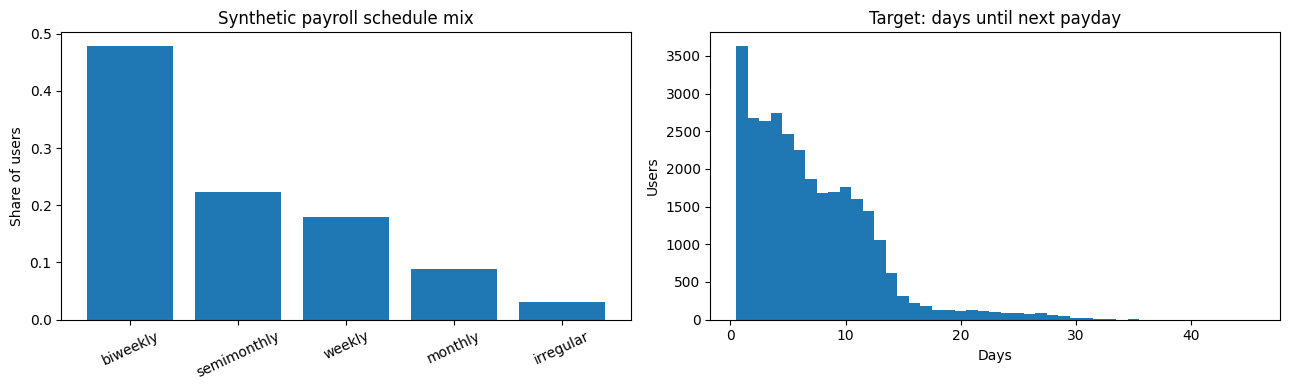

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

schedule_counts = (
    payday["true_schedule_for_analysis_only"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)
axes[0].bar(schedule_counts.index, schedule_counts.values)
axes[0].set_title("Synthetic payroll schedule mix")
axes[0].set_ylabel("Share of users")
axes[0].tick_params(axis="x", rotation=25)

axes[1].hist(
    payday["days_until_next_payday"],
    bins=np.arange(0.5, MAX_HORIZON_DAYS + 1.5, 1),
)
axes[1].set_title("Target: days until next payday")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()

In [9]:
schedule_summary = (
    payday.groupby("true_schedule_for_analysis_only", observed=True)
    .agg(
        users=("user_id", "size"),
        median_target_days=("days_until_next_payday", "median"),
        mean_interval=("mean_interval_days", "mean"),
        interval_volatility=("interval_std_days", "mean"),
        employer_change_rate=("recent_employer_change", "mean"),
    )
    .sort_values("users", ascending=False)
)
display(schedule_summary)

,users,median_target_days,mean_interval,interval_volatility,employer_change_rate
true_schedule_for_analysis_only,,,,,
biweekly,14353,6.0000,14.0053,0.5661,0.0828
semimonthly,6703,7.0000,15.0092,1.4159,0.0828
weekly,5401,3.0000,7.0105,0.2400,0.0874
monthly,2645,14.0000,30.0046,1.2021,0.0737
irregular,898,8.0000,19.0483,4.4981,0.0835


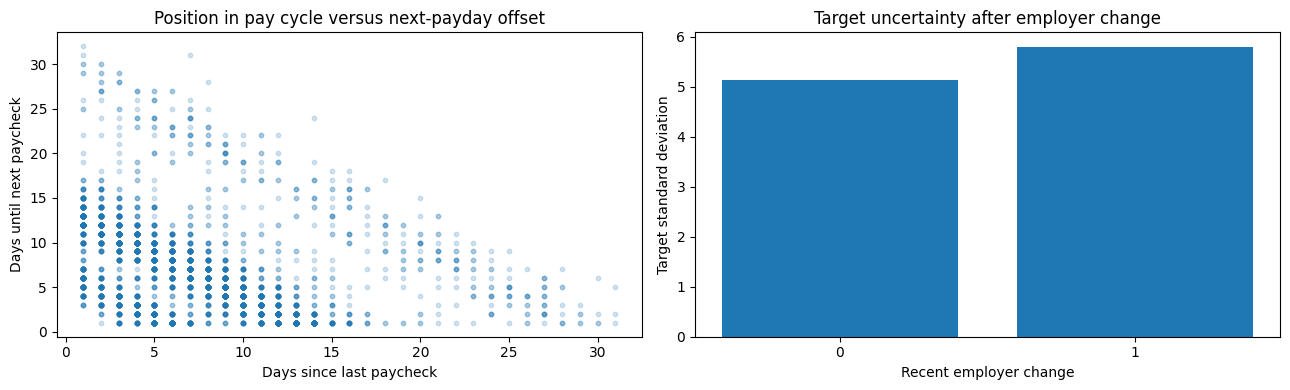

,mean,median,std
recent_employer_change,,,
0,6.9045,6.0000,5.1364
1,7.6829,6.0000,5.7942


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(
    payday["days_since_last_paycheck"].sample(4_000, random_state=RANDOM_STATE),
    payday.loc[
        payday.sample(4_000, random_state=RANDOM_STATE).index,
        "days_until_next_payday",
    ],
    alpha=0.20,
    s=10,
)
axes[0].set_title("Position in pay cycle versus next-payday offset")
axes[0].set_xlabel("Days since last paycheck")
axes[0].set_ylabel("Days until next paycheck")

change_summary = (
    payday.groupby("recent_employer_change")["days_until_next_payday"]
    .agg(["mean", "median", "std"])
)
axes[1].bar(change_summary.index.astype(str), change_summary["std"])
axes[1].set_title("Target uncertainty after employer change")
axes[1].set_xlabel("Recent employer change")
axes[1].set_ylabel("Target standard deviation")

plt.tight_layout()
plt.show()

display(change_summary)

## 7. Time-based train, validation, and test split

A random split would mix older and newer observations and can hide temporal drift. This notebook sorts by snapshot date:

- Earliest 70%: training
- Next 15%: validation and policy selection
- Latest 15%: untouched final test

The validation set controls XGBoost early stopping, quantile-policy selection, neural-network early stopping, and temperature scaling. The test set is used only for final reporting.

In [11]:
train_cutoff = payday["snapshot_date"].quantile(0.70)
validation_cutoff = payday["snapshot_date"].quantile(0.85)

train = payday.loc[payday["snapshot_date"] <= train_cutoff].copy()
validation = payday.loc[
    (payday["snapshot_date"] > train_cutoff)
    & (payday["snapshot_date"] <= validation_cutoff)
].copy()
test = payday.loc[payday["snapshot_date"] > validation_cutoff].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train), len(validation), len(test)],
        "start": [
            train["snapshot_date"].min(),
            validation["snapshot_date"].min(),
            test["snapshot_date"].min(),
        ],
        "end": [
            train["snapshot_date"].max(),
            validation["snapshot_date"].max(),
            test["snapshot_date"].max(),
        ],
        "target_mean": [
            train["days_until_next_payday"].mean(),
            validation["days_until_next_payday"].mean(),
            test["days_until_next_payday"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)
display(split_summary)
print({"train_cutoff": str(train_cutoff.date()), "validation_cutoff": str(validation_cutoff.date())})

,rows,start,end,target_mean
train,21024,2024-01-01,2025-05-16,6.9434
validation,4479,2025-05-17,2025-08-29,6.9920
test,4497,2025-08-30,2025-12-14,7.0652


{'train_cutoff': '2025-05-16', 'validation_cutoff': '2025-08-29'}


## 8. Feature definition and preprocessing

The true latent schedule and the target-date columns are explicitly excluded. Numeric values are median-imputed and standardized. Categorical values are imputed and one-hot encoded with unknown-category handling.

Scaling is unnecessary for trees but useful for the neural network, so one shared transform is used for a fair comparison.

In [12]:
TARGET = "days_until_next_payday"
NON_FEATURE_COLUMNS = [
    "user_id",
    "snapshot_date",
    "actual_next_payday",
    TARGET,
    "true_schedule_for_analysis_only",
]
FEATURES = [column for column in payday.columns if column not in NON_FEATURE_COLUMNS]
CATEGORICAL_FEATURES = [
    column for column in FEATURES if payday[column].dtype == "object"
]
NUMERIC_FEATURES = [
    column for column in FEATURES if column not in CATEGORICAL_FEATURES
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "one_hot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    sparse_threshold=0,
)

X_train = preprocessor.fit_transform(train[FEATURES]).astype(np.float32) # fit_transform learns preprocessing parameters and transforms training data.
X_validation = preprocessor.transform(validation[FEATURES]).astype(np.float32)
X_test = preprocessor.transform(test[FEATURES]).astype(np.float32)

y_train = train[TARGET].to_numpy(dtype=int)
y_validation = validation[TARGET].to_numpy(dtype=int)
y_test = test[TARGET].to_numpy(dtype=int)

encoded_feature_names = preprocessor.get_feature_names_out()

print({
    "raw_features": len(FEATURES), 
    "encoded_features": X_train.shape[1],
    "categorical_features": CATEGORICAL_FEATURES,
    "train_matrix": X_train.shape,
    "validation_matrix": X_validation.shape,
    "test_matrix": X_test.shape,
})

{'raw_features': 31, 'encoded_features': 49, 'categorical_features': ['inferred_cadence', 'employment_type', 'industry', 'bank_type', 'region'], 'train_matrix': (21024, 49), 'validation_matrix': (4479, 49), 'test_matrix': (4497, 49)}


In [13]:
data2= {
    "raw_features": len(FEATURES), 
    "encoded_features": X_train.shape[1],
    "categorical_features": CATEGORICAL_FEATURES,
    "train_matrix": X_train.shape,
    "validation_matrix": X_validation.shape,
    "test_matrix": X_test.shape,
}

print("\n".join(f"{k}: {v}" for k, v in data2.items()))

raw_features: 31
encoded_features: 49
categorical_features: ['inferred_cadence', 'employment_type', 'industry', 'bank_type', 'region']
train_matrix: (21024, 49)
validation_matrix: (4479, 49)
test_matrix: (4497, 49)


## 9. Evaluation framework

Standard date metrics:

- Mean absolute error in days
- Root mean squared error
- Exact-date accuracy
- Accuracy within one and two days

Customer and business metrics:

- Too-early rate
- Too-late rate
- Average days early and late
- Illustrative asymmetric cost

A model can have better MAE but worse business cost if its errors are biased toward early collection.

In [14]:
def realized_policy_cost(
    actual_days: np.ndarray,
    decision_days: np.ndarray,
    early_event_cost: float = EARLY_DEBIT_EVENT_COST,
    late_cost_per_day: float = LATE_RECOVERY_COST_PER_DAY,
) -> np.ndarray:
    actual = np.asarray(actual_days, dtype=int)
    decision = np.asarray(decision_days, dtype=int)
    early = decision < actual
    late_days = np.maximum(decision - actual, 0)
    return early.astype(float) * early_event_cost + late_days * late_cost_per_day


def evaluate_date_predictions(
    actual_days: np.ndarray,
    predicted_days: np.ndarray,
    model_name: str,
) -> dict[str, float | str]:
    actual = np.asarray(actual_days, dtype=int)
    predicted = np.clip(
        np.rint(predicted_days),
        1,
        MAX_HORIZON_DAYS,
    ).astype(int)
    error = predicted - actual

    return {
        "model": model_name,
        "mae_days": np.mean(np.abs(error)),
        "rmse_days": np.sqrt(np.mean(error ** 2)),
        "exact_date_accuracy": np.mean(error == 0),
        "within_1_day": np.mean(np.abs(error) <= 1),
        "within_2_days": np.mean(np.abs(error) <= 2),
        "too_early_rate": np.mean(error < 0),
        "too_late_rate": np.mean(error > 0),
        "avg_early_days": np.mean(np.maximum(-error, 0)),
        "avg_late_days": np.mean(np.maximum(error, 0)),
        "avg_business_cost": realized_policy_cost(actual, predicted).mean(),
    }


def prediction_dates(frame: pd.DataFrame, predicted_days: np.ndarray) -> pd.Series:
    clipped_days = np.clip(
        np.rint(predicted_days),
        1,
        MAX_HORIZON_DAYS,
    ).astype(int)
    return frame["snapshot_date"] + pd.to_timedelta(clipped_days, unit="D")

## 10. Baselines

A serious ML project should beat transparent baselines.

1. **Last interval:** assume the next paycheck interval equals the most recent interval.
2. **Median interval:** assume the next paycheck interval equals the median of recent intervals.

The prediction is the estimated full interval minus the number of days already elapsed since the previous paycheck.

In [15]:
def interval_baseline(frame: pd.DataFrame, interval_column: str) -> np.ndarray:
    return np.maximum(
        1,
        frame[interval_column].to_numpy()
        - frame["days_since_last_paycheck"].to_numpy(),
    )

validation_last_interval = interval_baseline(validation, "last_interval_days")
validation_median_interval = interval_baseline(validation, "median_interval_days")

test_last_interval = interval_baseline(test, "last_interval_days")
test_median_interval = interval_baseline(test, "median_interval_days")

baseline_results = pd.DataFrame(
    [
        evaluate_date_predictions(y_test, test_last_interval, "Baseline: last interval"),
        evaluate_date_predictions(y_test, test_median_interval, "Baseline: median interval"),
    ]
).set_index("model")

display(baseline_results)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
Baseline: last interval,1.5762,2.5019,0.2851,0.6380,0.8101,0.2697,0.4452,0.5879,0.9882,10.1819
Baseline: median interval,1.3878,2.1777,0.3131,0.6785,0.8455,0.2760,0.4109,0.5944,0.7934,10.2537


## 11. XGBoost point-regression model

The point model uses the absolute-error objective because payday errors have outliers from employer changes, irregular work, holidays, and posting delays.

Early stopping is controlled by the chronological validation set.

In [16]:
XGB_COMMON_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 5,
    "min_child_weight": 6,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 6.0,
    "reg_alpha": 0.05,
    "tree_method": "hist", # Instead of testing every unique numeric value as a possible split, continuous values are grouped into bins. XGBoost then evaluates splits between those bins. The official documentation describes hist as a faster, histogram-optimized approximate greedy algorithm
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "early_stopping_rounds": 35,
}

xgb_point = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    eval_metric="mae",
    **XGB_COMMON_PARAMS,
)

xgb_point.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False,
)

validation_point_prediction = xgb_point.predict(X_validation)
test_point_prediction = xgb_point.predict(X_test)

print({
    "best_iteration": int(xgb_point.best_iteration),
    "best_validation_mae": float(xgb_point.best_score),
})

{'best_iteration': 309, 'best_validation_mae': 1.1751743815764435}


In [17]:
point_result = pd.DataFrame(
    [
        evaluate_date_predictions(
            y_test,
            test_point_prediction,
            "XGBoost point estimate",
        )
    ]
).set_index("model")

display(point_result)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
XGBoost point estimate,1.2186,2.0863,0.4234,0.7338,0.8372,0.2940,0.2826,0.6793,0.5392,10.6935


### Why the point model is not the final debit policy

The point estimate is optimized to be near the center of the target distribution. It does not know that a one-day early error can be more harmful than a several-day late error.

The result below often shows the central interview insight: **better date accuracy can coexist with worse business cost**.

In [18]:
point_vs_baseline = pd.concat(
    [
        baseline_results.loc[["Baseline: median interval"]],
        point_result,
    ]
)
display(point_vs_baseline)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
Baseline: median interval,1.3878,2.1777,0.3131,0.6785,0.8455,0.2760,0.4109,0.5944,0.7934,10.2537
XGBoost point estimate,1.2186,2.0863,0.4234,0.7338,0.8372,0.2940,0.2826,0.6793,0.5392,10.6935


## 12. XGBoost feature importance

Gain importance identifies features that most reduced the tree objective. It is useful for debugging and prioritization, but it is not causal and should not be interpreted as a percentage of business impact.

,feature,importance
1,numeric__median_interval_days,0.1742
4,numeric__last_interval_days,0.1251
0,numeric__days_since_last_paycheck,0.1195
2,numeric__mean_interval_days,0.1169
9,numeric__observed_paychecks_90d,0.0576
10,numeric__dominant_pay_weekday,0.0422
13,numeric__recent_employer_change,0.0343
15,numeric__snapshot_weekday,0.0253
12,numeric__schedule_consistency,0.0239
3,numeric__interval_std_days,0.0227


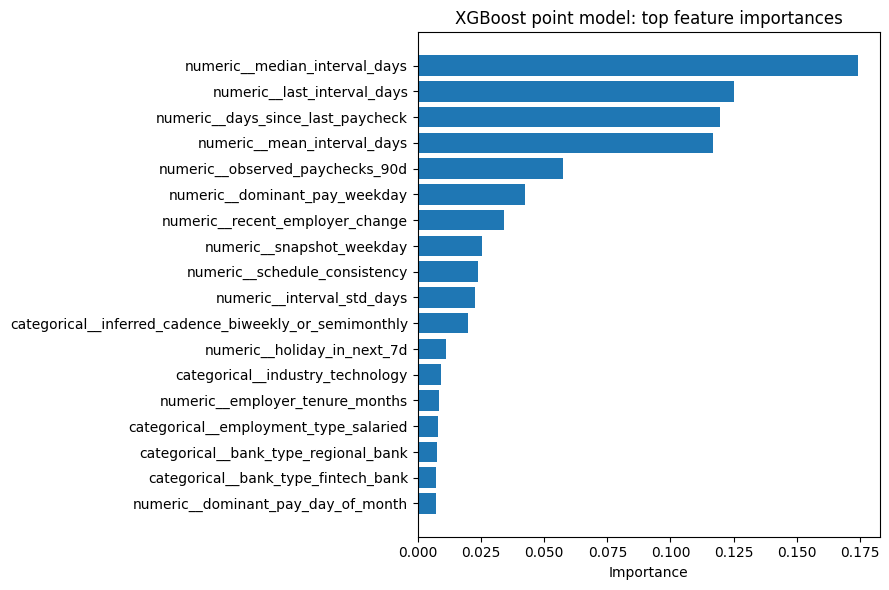

In [19]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": encoded_feature_names,
            "importance": xgb_point.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(18)
)

display(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1],
)
plt.title("XGBoost point model: top feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 13. XGBoost upper-quantile model

A quantile model estimates a conditional upper percentile of the payday offset.

For a 90th-percentile model:

$$
P(Y \le \widehat q_{0.90}(X) \mid X) \approx 0.90
$$

Using the upper quantile as a debit date should reduce the probability that the actual paycheck arrives later than the chosen date.

Quantile coverage is not guaranteed under drift, misspecification, or small segments, so the validation set is also used to select a small global safety offset.

In [20]:
xgb_q90 = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.90,
    eval_metric="quantile",
    **XGB_COMMON_PARAMS,
)

xgb_q90.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False,
)

validation_q90_prediction = xgb_q90.predict(X_validation)
test_q90_prediction = xgb_q90.predict(X_test)

print({
    "best_iteration": int(xgb_q90.best_iteration),
    "best_validation_quantile_loss": float(xgb_q90.best_score),
})

{'best_iteration': 254, 'best_validation_quantile_loss': 0.29332619565619117}


## 14. Select the collection policy on validation data

Two possible policy objectives are demonstrated:

1. **Minimum expected realized cost** under the illustrative cost assumptions.
2. **Risk cap:** choose the smallest offset whose validation too-early rate is at or below 5%.

A production team might combine these with ACH processing windows, account authorization, current balance, retry limits, and customer communication.

In [21]:
policy_rows = []
for safety_offset in range(0, 8):
    row = evaluate_date_predictions(
        y_validation,
        validation_q90_prediction + safety_offset,
        f"q90 + {safety_offset} day(s)",
    )
    row["safety_offset"] = safety_offset
    policy_rows.append(row)

validation_policy_table = pd.DataFrame(policy_rows).set_index("safety_offset")
display(validation_policy_table[
    [
        "mae_days",
        "too_early_rate",
        "too_late_rate",
        "avg_business_cost",
    ]
])

cost_optimal_offset = int(
    validation_policy_table["avg_business_cost"].idxmin()
)

eligible_risk_offsets = validation_policy_table.loc[
    validation_policy_table["too_early_rate"] <= TARGET_MAX_EARLY_RATE
]
risk_cap_offset = int(
    eligible_risk_offsets.index.min()
    if not eligible_risk_offsets.empty
    else validation_policy_table.index.max()
)

print({
    "cost_optimal_offset": cost_optimal_offset,
    "risk_cap_offset": risk_cap_offset,
    "validation_early_rate_at_risk_cap": float(
        validation_policy_table.loc[risk_cap_offset, "too_early_rate"]
    ),
})

,mae_days,too_early_rate,too_late_rate,avg_business_cost
safety_offset,,,,
0,2.1400,0.0551,0.7890,3.4668
1,3.0297,0.0199,0.9449,2.9408
2,3.9900,0.0094,0.9801,3.3086
3,4.9712,0.0038,0.9906,3.8562
4,5.9636,0.0016,0.9962,4.5252
5,6.9605,0.0011,0.9984,5.2584
6,7.9582,0.0002,0.9989,5.9763
7,8.9578,0.0000,0.9998,6.7184


{'cost_optimal_offset': 1, 'risk_cap_offset': 1, 'validation_early_rate_at_risk_cap': 0.019870506809555703}


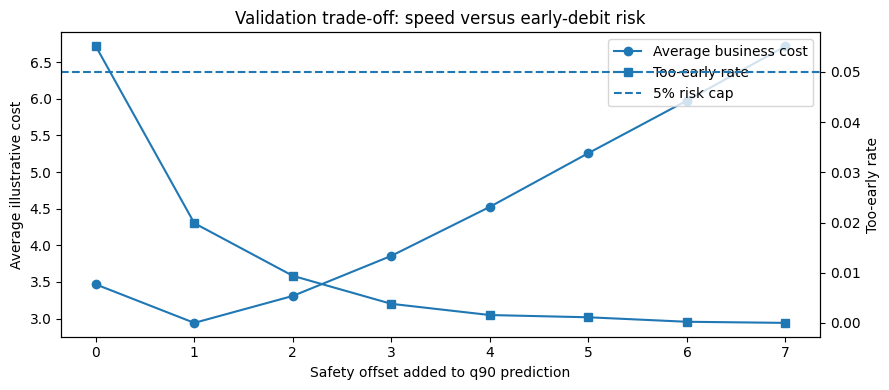

In [22]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(
    validation_policy_table.index,
    validation_policy_table["avg_business_cost"],
    marker="o",
    label="Average business cost",
)
ax1.set_xlabel("Safety offset added to q90 prediction")
ax1.set_ylabel("Average illustrative cost")

ax2 = ax1.twinx()
ax2.plot(
    validation_policy_table.index,
    validation_policy_table["too_early_rate"],
    marker="s",
    label="Too-early rate",
)
ax2.axhline(TARGET_MAX_EARLY_RATE, linestyle="--", label="5% risk cap")
ax2.set_ylabel("Too-early rate")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
plt.title("Validation trade-off: speed versus early-debit risk")
plt.tight_layout()
plt.show()

## 15. Final XGBoost test evaluation

No policy setting below is selected from the test set.

In [23]:
test_xgb_safe_prediction = test_q90_prediction + risk_cap_offset

xgb_results = pd.DataFrame(
    [
        evaluate_date_predictions(
            y_test,
            test_median_interval,
            "Baseline: median interval",
        ),
        evaluate_date_predictions(
            y_test,
            test_point_prediction,
            "XGBoost point estimate",
        ),
        evaluate_date_predictions(
            y_test,
            test_q90_prediction,
            "XGBoost q90",
        ),
        evaluate_date_predictions(
            y_test,
            test_xgb_safe_prediction,
            f"XGBoost q90 + {risk_cap_offset}-day safety offset",
        ),
    ]
).set_index("model")

display(xgb_results)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
Baseline: median interval,1.3878,2.1777,0.3131,0.6785,0.8455,0.2760,0.4109,0.5944,0.7934,10.2537
XGBoost point estimate,1.2186,2.0863,0.4234,0.7338,0.8372,0.2940,0.2826,0.6793,0.5392,10.6935
XGBoost q90,2.1441,3.0263,0.1548,0.5030,0.6911,0.0634,0.7819,0.1110,2.0331,3.7430
XGBoost q90 + 1-day safety offset,3.0173,3.7420,0.0396,0.2066,0.5210,0.0238,0.9366,0.0476,2.9698,3.0601


### Interpretation

Typical outcome in this synthetic experiment:

- The point model has the best MAE and exact-date accuracy.
- It can still produce many early predictions because absolute error treats early and late errors similarly.
- The q90 policy gives up exact-date accuracy to dramatically reduce early-debit risk.
- Under the illustrative $35 early-event cost, the conservative policy produces a much lower average cost.

This is why the final production output should be a **policy date and confidence/risk estimate**, not merely a raw regression prediction.

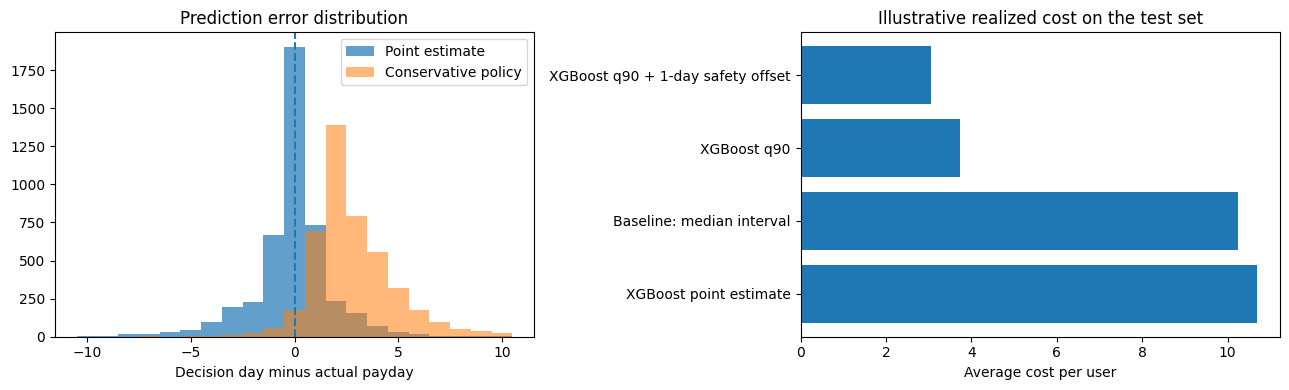

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

point_error = np.rint(test_point_prediction).astype(int) - y_test
safe_error = np.rint(test_xgb_safe_prediction).astype(int) - y_test

bins = np.arange(-10.5, 11.5, 1)
axes[0].hist(point_error, bins=bins, alpha=0.70, label="Point estimate")
axes[0].hist(safe_error, bins=bins, alpha=0.55, label="Conservative policy")
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Prediction error distribution")
axes[0].set_xlabel("Decision day minus actual payday")
axes[0].legend()

policy_costs = xgb_results["avg_business_cost"].sort_values()
axes[1].barh(policy_costs.index[::-1], policy_costs.values[::-1])
axes[1].set_title("Illustrative realized cost on the test set")
axes[1].set_xlabel("Average cost per user")

plt.tight_layout()
plt.show()

## 16. Uncertainty and abstention

The distance between the q90 and point estimates is a simple uncertainty proxy. A production service can avoid automatic collection when the model is unusually uncertain and instead:

- Wait for more evidence
- Send a reminder rather than initiating a debit
- Ask the customer to confirm the date
- Route to a safer manual or rules-based process

The table below shows a coverage-versus-risk curve. Lower uncertainty thresholds automate fewer users.

In [25]:
uncertainty_width = np.maximum(
    test_q90_prediction - test_point_prediction,
    0,
) # output: array([8.006611 , 2.9716873, 1.7432842, ..., 5.4032006, 1.1650623, 1.1735212], dtype=float32)

coverage_rows = []
for percentile in [25, 40, 55, 70, 85, 100]:
    width_threshold = np.percentile(uncertainty_width, percentile)
    automated = uncertainty_width <= width_threshold
    metrics = evaluate_date_predictions(
        y_test[automated],
        test_xgb_safe_prediction[automated],
        f"lowest uncertainty {percentile}%",
    )
    metrics.update(
        {
            "coverage": automated.mean(),
            "width_threshold": width_threshold,
            "users": automated.sum(),
        }
    )
    coverage_rows.append(metrics)

xgb_coverage_table = pd.DataFrame(coverage_rows).set_index("model")
display(
    xgb_coverage_table[
        [
            "users",
            "coverage",
            "width_threshold",
            "too_early_rate",
            "avg_business_cost",
            "mae_days",
        ]
    ]
)

,users,coverage,width_threshold,too_early_rate,avg_business_cost,mae_days
model,,,,,,
lowest uncertainty 25%,1125,0.2502,1.0027,0.0080,1.7093,1.9182
lowest uncertainty 40%,1799,0.4000,1.1322,0.0067,1.7418,2.0206
lowest uncertainty 55%,2473,0.5499,1.6768,0.0121,2.0104,2.1314
lowest uncertainty 70%,3148,0.7000,2.4482,0.0149,2.2780,2.3618
lowest uncertainty 85%,3822,0.8499,3.2923,0.0149,2.4190,2.5508
lowest uncertainty 100%,4497,1.0000,9.8413,0.0238,3.0601,3.0173


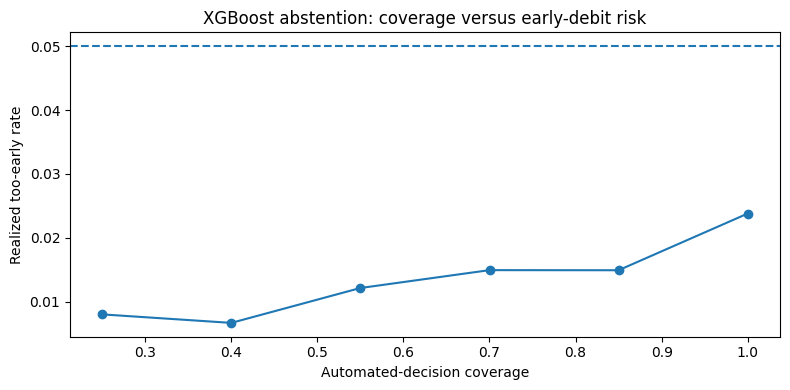

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(
    xgb_coverage_table["coverage"],
    xgb_coverage_table["too_early_rate"],
    marker="o",
)
plt.axhline(TARGET_MAX_EARLY_RATE, linestyle="--")
plt.xlabel("Automated-decision coverage")
plt.ylabel("Realized too-early rate")
plt.title("XGBoost abstention: coverage versus early-debit risk")
plt.tight_layout()
plt.show()

## 17. Segment diagnostics

Aggregate metrics can hide harmful failures. The same metrics should be measured by:

- Inferred cadence
- Employer change status
- Bank and processor
- Region and legally permitted geography
- Employment type
- Amount owed and balance bands
- New versus established accounts
- Holiday and month-end periods

The goal is not to create different customer protections for different groups. It is to detect where the model is unreliable and apply stronger safeguards.

In [27]:
def segment_policy_metrics(
    frame: pd.DataFrame,
    actual: np.ndarray,
    decision: np.ndarray,
    segment_column: str,
) -> pd.DataFrame:
    local = frame[[segment_column]].copy()
    local["actual"] = actual
    local["decision"] = np.clip(
        np.rint(decision), 1, MAX_HORIZON_DAYS
    ).astype(int)
    local["error"] = local["decision"] - local["actual"]
    local["cost"] = realized_policy_cost(local["actual"], local["decision"])

    return (
        local.groupby(segment_column, observed=True)
        .agg(
            users=("actual", "size"),
            mae_days=("error", lambda values: np.mean(np.abs(values))),
            too_early_rate=("error", lambda values: np.mean(values < 0)),
            too_late_rate=("error", lambda values: np.mean(values > 0)),
            avg_business_cost=("cost", "mean"),
        )
        .sort_values("avg_business_cost", ascending=False)
    )

cadence_metrics = segment_policy_metrics(
    test,
    y_test,
    test_xgb_safe_prediction,
    "inferred_cadence",
)
change_metrics = segment_policy_metrics(
    test,
    y_test,
    test_xgb_safe_prediction,
    "recent_employer_change",
)

display(cadence_metrics)
display(change_metrics)

,users,mae_days,too_early_rate,too_late_rate,avg_business_cost
inferred_cadence,,,,,
irregular,159,6.7547,0.1006,0.8742,8.3522
monthly,399,3.2732,0.0752,0.8647,4.9962
biweekly_or_semimonthly,3153,2.9315,0.0178,0.9401,2.7941
weekly,786,2.4758,0.0064,0.9720,2.0738


,users,mae_days,too_early_rate,too_late_rate,avg_business_cost
recent_employer_change,,,,,
1,466,5.5193,0.0751,0.8841,6.6282
0,4031,2.7281,0.0179,0.9427,2.6476


## 18. Optional neural-network benchmark

The neural network treats the target as a discrete probability distribution over days 1 through 45.

Advantages:

- Produces a complete probability mass function
- Supports arbitrary expected-cost policies
- Can learn nonlinear interactions
- Can later be extended to transaction sequences, embeddings, or transformers

Disadvantages:

- More sensitive to feature scaling and optimization
- Harder to debug and govern
- Often unnecessary for small tabular data
- Probability calibration requires explicit attention

For this tabular synthetic problem, XGBoost is expected to remain highly competitive.

In [ ]:
if RUN_NEURAL_NETWORK:
    class PaydayMLP(nn.Module):
        def __init__(self, input_dim: int, horizon_days: int):
            super().__init__()
            self.network = nn.Sequential(
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128), #Calculates its batch mean ;Calculates its batch variance; Normalizes the values. More stable; Less sensitive to initialization; Faster to converge
                nn.Dropout(0.15), # activates in train mode, but not activates in val mode
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.10),
                nn.Linear(64, horizon_days),
            )

        def forward(self, features: torch.Tensor) -> torch.Tensor:
            return self.network(features)

    class_frequency = np.bincount(
        y_train,
        minlength=MAX_HORIZON_DAYS + 1,
    )[1:]
    class_weights = np.sqrt(
        class_frequency.sum() / np.maximum(class_frequency, 1)
    )
    # This normalizes the weights so their mean is 1.
    class_weights = class_weights / class_weights.mean()

    # This creates the neural-network object.
    neural_network = PaydayMLP(
        input_dim=X_train.shape[1],
        horizon_days=MAX_HORIZON_DAYS,
    )

    # AdamW handles weight decay differently—and generally more cleanly—than classical Adam with an L2 penalty.
    optimizer = torch.optim.AdamW(
        neural_network.parameters(),
        lr=2e-3,
        weight_decay=1e-4, # Large model weights can be associated with overfitting. Weight decay gently pulls parameters toward zero.
    )

    # Defining the loss function: For each observation, it: Converts the logits into a probability distribution internally. Looks at the probability assigned to the correct target day. Penalizes the model when that probability is low The class-weight tensor tells the loss function to penalize mistakes on rare days more strongly.
    loss_function = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32) # The class weights began as a NumPy array. This converts them into a PyTorch tensor.
    )

    # A DataLoader divides the training data into batches and provides them during training.
    train_loader = DataLoader(
        # A TensorDataset pairs the feature tensor and target tensor.
        TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train - 1, dtype=torch.long),
        ),
        batch_size=512,
        shuffle=True,
    )

    validation_features_tensor = torch.tensor(
        X_validation,
        dtype=torch.float32,
    )
    validation_target_tensor = torch.tensor(
        y_validation - 1,
        dtype=torch.long,
    )

    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    patience = 5
    training_history = []

    for epoch in range(30):
        # This switches the model into training mode. It particularly affects: Dropout: activated. Batch normalization: uses batch statistics and updates running statistics 
        neural_network.train()
        total_training_loss = 0.0

        for feature_batch, target_batch in train_loader:
            optimizer.zero_grad() # PyTorch accumulates gradients by default. Without clearing them, the current batch’s gradients would be added to gradients left over from earlier batches.
            logits = neural_network(feature_batch) # Forward pass: The feature batch passes through the neural network.
            loss = loss_function(logits, target_batch) # Calculating batch loss: This compares the 45(MAX_HORIZON_DAYS) predicted logits against the correct class for each observation. Because class weights were provided, errors on uncommon target days may contribute more heavily.
            loss.backward() # This calculates the gradient of the loss with respect to every trainable model parameter.
            optimizer.step() # Parameter update: AdamW uses the newly calculated gradients to update the model parameters. This is the line where learning actually occurs.
            total_training_loss += loss.item() * len(feature_batch)

        # This switches the model into evaluation mode. Dropout is turned off. Batch normalization uses learned running statistics rather than current-batch statistics
        neural_network.eval() 
        with torch.no_grad(): # Disabling gradient calculation
            validation_logits_tensor = neural_network(validation_features_tensor) # Validation prediction: The entire validation feature matrix passes through the model. Because the model is in evaluation mode, dropout is disabled.
            validation_loss = loss_function( # This compares validation predictions with validation targets. Validation loss answers: How well does the model generalize to observations that were not used for gradient updates?
                validation_logits_tensor,
                validation_target_tensor,
            ).item() # .item() converts the scalar loss tensor into a Python floating-point value.

        average_training_loss = total_training_loss / len(X_train) # This divides the accumulated loss by the number of training observations. The result is the reported average loss for that epoch. As noted earlier, it is an approximate weighted-loss average because the loss function uses class weights.
        training_history.append(
            {
                "epoch": epoch + 1,
                "training_loss": average_training_loss,
                "validation_loss": validation_loss,
            }
        )

        # This checks whether validation loss improved by at least: 1e-4 = 0.0001 The small threshold prevents extremely tiny floating-point changes from resetting early stopping.
        if validation_loss < best_validation_loss - 1e-4: 
            best_validation_loss = validation_loss
            best_state = {
                key: value.detach().clone()
                for key, value in neural_network.state_dict().items() # state_dict() contains items such as: Linear weights. Linear biases. Batch-normalization parameters. Batch-normalization running means. Batch-normalization running variances
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    neural_network.load_state_dict(best_state) # Restoring the best model: The model’s parameters are restored to the best validation epoch.
    training_history = pd.DataFrame(training_history)

    print({
        "epochs_trained": len(training_history),
        "best_validation_loss": best_validation_loss,
    })
    display(training_history.tail())
else:
    print("PyTorch is unavailable; the neural-network section is skipped.")

{'epochs_trained': 18, 'best_validation_loss': 1.789300560951233}


,epoch,training_loss,validation_loss
13,14,1.7268,1.8024
14,15,1.7077,1.7956
15,16,1.6957,1.7932
16,17,1.6887,1.7949
17,18,1.6640,1.7967


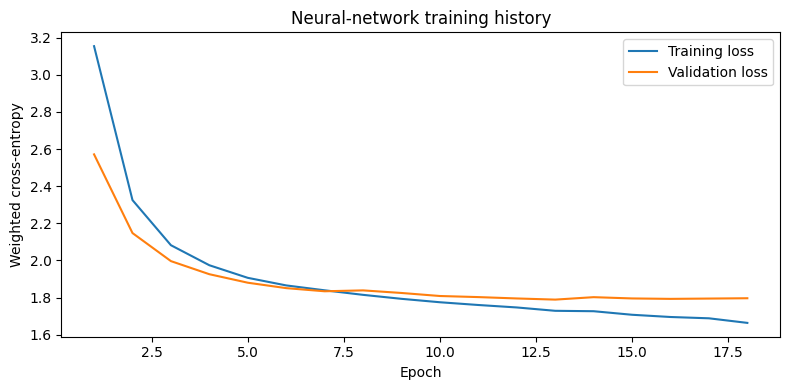

In [29]:
if RUN_NEURAL_NETWORK:
    plt.figure(figsize=(8, 4))
    plt.plot(
        training_history["epoch"],
        training_history["training_loss"],
        label="Training loss",
    )
    plt.plot(
        training_history["epoch"],
        training_history["validation_loss"],
        label="Validation loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Weighted cross-entropy")
    plt.title("Neural-network training history")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Temperature scaling

The raw softmax output is calibrated on the validation set with a single temperature. This preserves class ranking while adjusting confidence.

In [ ]:
if RUN_NEURAL_NETWORK:
    # This puts the trained model into evaluation mode. It changes the behavior of certain layers: Dropout is disabled Batch normalization uses its stored running statistics Predictions become deterministic
    neural_network.eval()
    with torch.no_grad(): # Turning off gradient tracking: Inside this block, PyTorch does not construct a gradient-computation graph.
        validation_nn_logits = neural_network( # The model returns one logit for each possible payday horizon. Assuming MAX_HORIZON_DAYS = 45, the result has shape: (number_of_validation_rows, 45) For one customer, the output might look approximately like: [-1.4, -0.9, -0.1, 0.2, ..., 2.1, ..., -0.7] These are raw scores, not probabilities. They: Can be negative Do not sum to 1 Can be any real number
            torch.tensor(X_validation, dtype=torch.float32)
        ).numpy()
        test_nn_logits = neural_network(
            torch.tensor(X_test, dtype=torch.float32)
        ).numpy()

    temperature_grid = np.linspace(0.50, 2.50, 41) # This generates 41 evenly spaced candidate temperatures between 0.50 and 2.50, inclusive.
    temperature_losses = [
        log_loss( # log_loss is scikit-learn’s multiclass logarithmic loss. It evaluates how much probability the model assigned to the true class. For one observation whose true target is class y, its contribution is approximately: −log(P(y)) Examples: Probability assigned to correct class: 0.90 Loss: -log(0.90) ≈ 0.105 Probability assigned to correct class: 0.50 Loss: -log(0.50) ≈ 0.693
            y_validation - 1,
            softmax(validation_nn_logits / temperature, axis=1), # axis=1 means softmax is calculated across the class columns.
            labels=np.arange(MAX_HORIZON_DAYS), # This tells log_loss that there are exactly 45 possible classes. It is particularly important when a validation split happens not to contain one of the classes. Without labels, scikit-learn might infer an incomplete class set or report a shape mismatch.
        )
        for temperature in temperature_grid
    ]
    selected_temperature = float(
        temperature_grid[int(np.argmin(temperature_losses))]
    )

    validation_nn_probability = softmax(
        validation_nn_logits / selected_temperature,
        axis=1,
    )
    test_nn_probability = softmax(
        test_nn_logits / selected_temperature,
        axis=1,
    )

    print({
        "selected_temperature": selected_temperature,
        "validation_log_loss": min(temperature_losses),
    })

{'selected_temperature': 0.95, 'validation_log_loss': 1.6251454626731516}


In [38]:
uncalibrated_validation_loss = log_loss(
    y_validation - 1,
    softmax(validation_nn_logits, axis=1),
    labels=np.arange(MAX_HORIZON_DAYS),
)

calibrated_validation_loss = log_loss(
    y_validation - 1,
    validation_nn_probability,
    labels=np.arange(MAX_HORIZON_DAYS),
)
print({
    "uncalibrated_log_loss": uncalibrated_validation_loss,
    "calibrated_log_loss": calibrated_validation_loss,
    "improvement": (
        uncalibrated_validation_loss
        - calibrated_validation_loss
    ),
})

{'uncalibrated_log_loss': 1.6255076698964075, 'calibrated_log_loss': 1.6251454416100455, 'improvement': 0.00036222828636200965}


### Probability-to-decision policy

For each possible decision day \(d\), calculate expected cost over all possible true payday days \(y\):

$$
E[C(d,Y) \mid X] = \sum_y P(Y=y\mid X) C(d,y)
$$

where:

$$
C(d,y) =
\begin{cases}
35, & d < y \\
0.75(d-y), & d \ge y
\end{cases}
$$

The chosen day is the one with minimum expected cost.

In [31]:
def make_cost_matrix(
    horizon_days: int,
    early_event_cost: float,
    late_cost_per_day: float,
) -> np.ndarray:
    days = np.arange(1, horizon_days + 1)
    cost_matrix = np.zeros((horizon_days, horizon_days), dtype=float)
    for true_index, true_day in enumerate(days):
        for decision_index, decision_day in enumerate(days):
            cost_matrix[true_index, decision_index] = (
                early_event_cost
                if decision_day < true_day
                else late_cost_per_day * (decision_day - true_day)
            )
    return cost_matrix


if RUN_NEURAL_NETWORK:
    nn_cost_matrix = make_cost_matrix(
        MAX_HORIZON_DAYS,
        EARLY_DEBIT_EVENT_COST,
        LATE_RECOVERY_COST_PER_DAY,
    )

    test_nn_argmax_prediction = test_nn_probability.argmax(axis=1) + 1
    test_nn_expected_cost = test_nn_probability @ nn_cost_matrix
    test_nn_cost_optimal_prediction = test_nn_expected_cost.argmin(axis=1) + 1

    nn_results = pd.DataFrame(
        [
            evaluate_date_predictions(
                y_test,
                test_nn_argmax_prediction,
                "Neural network: most likely day",
            ),
            evaluate_date_predictions(
                y_test,
                test_nn_cost_optimal_prediction,
                "Neural network: minimum expected cost",
            ),
        ]
    ).set_index("model")

    display(nn_results)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
Neural network: most likely day,1.3925,2.4802,0.4098,0.7134,0.8201,0.3142,0.2760,0.6820,0.7105,11.5302
Neural network: minimum expected cost,3.2133,4.3097,0.0618,0.2646,0.5279,0.0218,0.9164,0.0380,3.1752,3.1442


## 19. Model and policy comparison

The appropriate comparison is not simply XGBoost versus neural network. Each model can support multiple decision policies.

In [32]:
comparison_frames = [xgb_results]
if RUN_NEURAL_NETWORK:
    comparison_frames.append(nn_results)

final_comparison = pd.concat(comparison_frames).sort_values("avg_business_cost")
display(final_comparison)

,mae_days,rmse_days,exact_date_accuracy,within_1_day,within_2_days,too_early_rate,too_late_rate,avg_early_days,avg_late_days,avg_business_cost
model,,,,,,,,,,
XGBoost q90 + 1-day safety offset,3.0173,3.7420,0.0396,0.2066,0.5210,0.0238,0.9366,0.0476,2.9698,3.0601
Neural network: minimum expected cost,3.2133,4.3097,0.0618,0.2646,0.5279,0.0218,0.9164,0.0380,3.1752,3.1442
XGBoost q90,2.1441,3.0263,0.1548,0.5030,0.6911,0.0634,0.7819,0.1110,2.0331,3.7430
Baseline: median interval,1.3878,2.1777,0.3131,0.6785,0.8455,0.2760,0.4109,0.5944,0.7934,10.2537
XGBoost point estimate,1.2186,2.0863,0.4234,0.7338,0.8372,0.2940,0.2826,0.6793,0.5392,10.6935
Neural network: most likely day,1.3925,2.4802,0.4098,0.7134,0.8201,0.3142,0.2760,0.6820,0.7105,11.5302


### Expected conclusion

- XGBoost point regression is strongest for central date accuracy.
- XGBoost q90 plus a validation-selected safety offset is strongest or nearly strongest for the asymmetric business objective.
- The neural network is competitive but does not clearly justify its additional operational complexity on this tabular dataset.
- A neural model may become more valuable when raw transaction sequences, merchant text embeddings, employer embeddings, or long temporal histories are available.

## 20. Neural-network abstention curve

Maximum calibrated probability is used as a simple confidence score. A production implementation could also use entropy, ensemble disagreement, conformal prediction sets, or out-of-distribution scores.

In [33]:
if RUN_NEURAL_NETWORK:
    maximum_probability = test_nn_probability.max(axis=1)
    confidence_rows = []

    for confidence_threshold in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
        automated = maximum_probability >= confidence_threshold
        if automated.sum() == 0:
            continue

        metrics = evaluate_date_predictions(
            y_test[automated],
            test_nn_cost_optimal_prediction[automated],
            f"max probability >= {confidence_threshold:.2f}",
        )
        metrics.update(
            {
                "users": automated.sum(),
                "coverage": automated.mean(),
                "confidence_threshold": confidence_threshold,
            }
        )
        confidence_rows.append(metrics)

    nn_confidence_table = pd.DataFrame(confidence_rows).set_index("model")
    display(
        nn_confidence_table[
            [
                "users",
                "coverage",
                "too_early_rate",
                "avg_business_cost",
                "mae_days",
            ]
        ]
    )

,users,coverage,too_early_rate,avg_business_cost,mae_days
model,,,,,
max probability >= 0.15,4311,0.9586,0.0220,2.9513,2.9455
max probability >= 0.20,4058,0.9024,0.0227,2.7794,2.6880
max probability >= 0.25,3676,0.8174,0.0220,2.6338,2.5204
max probability >= 0.30,3155,0.7016,0.0209,2.4666,2.3442
max probability >= 0.40,1885,0.4192,0.0196,2.2336,2.0907
max probability >= 0.50,882,0.1961,0.0227,2.2588,1.9830


## 21. Example user-level predictions

A production API should return more than a date. It should return the point estimate, conservative date, uncertainty, model version, and a decision recommendation.

In [34]:
example_count = 12
example_index = test.sample(example_count, random_state=RANDOM_STATE).index
example_position = test.index.get_indexer(example_index)

prediction_examples = test.loc[
    example_index,
    [
        "user_id",
        "snapshot_date",
        "actual_next_payday",
        "inferred_cadence",
        "recent_employer_change",
        "days_since_last_paycheck",
        "median_interval_days",
        "current_balance",
        "amount_owed",
    ],
].copy()

prediction_examples["xgb_point_date"] = prediction_dates(
    test.iloc[example_position],
    test_point_prediction[example_position],
).to_numpy()
prediction_examples["xgb_safe_date"] = prediction_dates(
    test.iloc[example_position],
    test_xgb_safe_prediction[example_position],
).to_numpy()
prediction_examples["xgb_uncertainty_width_days"] = uncertainty_width[
    example_position
]

if RUN_NEURAL_NETWORK:
    prediction_examples["nn_cost_optimal_date"] = prediction_dates(
        test.iloc[example_position],
        test_nn_cost_optimal_prediction[example_position],
    ).to_numpy()
    prediction_examples["nn_max_probability"] = maximum_probability[
        example_position
    ]

display(prediction_examples.sort_values("snapshot_date"))

,user_id,snapshot_date,actual_next_payday,inferred_cadence,recent_employer_change,days_since_last_paycheck,median_interval_days,current_balance,amount_owed,xgb_point_date,xgb_safe_date,xgb_uncertainty_width_days,nn_cost_optimal_date,nn_max_probability
16925,U016925,2025-09-25,2025-09-26,irregular,0,30,19.0000,294.4213,141.2307,2025-09-26,2025-10-02,5.5293,2025-09-27,0.8285
12013,U012013,2025-09-29,2025-09-30,weekly,0,6,7.0000,-600.0000,471.6329,2025-09-30,2025-10-02,1.1529,2025-10-02,0.6959
20967,U020967,2025-10-01,2025-10-06,biweekly_or_semimonthly,0,9,14.0000,52.3571,244.2214,2025-10-06,2025-10-08,1.0774,2025-10-08,0.2330
8561,U008561,2025-10-11,2025-10-23,biweekly_or_semimonthly,0,2,14.0000,-575.3050,314.5146,2025-10-23,2025-10-25,0.8920,2025-10-24,0.4063
943,U000943,2025-10-30,2025-11-07,biweekly_or_semimonthly,0,6,14.0000,427.8325,264.0810,2025-11-07,2025-11-07,0.0000,2025-11-08,0.4040
24888,U024888,2025-11-03,2025-11-07,biweekly_or_semimonthly,0,9,14.0000,459.7464,126.9374,2025-11-07,2025-11-09,1.3149,2025-11-07,0.6227
8125,U008125,2025-11-03,2025-11-05,biweekly_or_semimonthly,0,12,14.0000,"2,244.8291",284.1843,2025-11-05,2025-11-07,1.0076,2025-11-07,0.3989
29481,U029481,2025-11-08,2025-11-21,irregular,0,2,20.5000,-214.6081,273.5416,2025-11-22,2025-11-30,6.8237,2025-12-09,0.1741
9679,U009679,2025-11-22,2025-11-26,biweekly_or_semimonthly,0,12,14.0000,746.6058,356.9673,2025-11-24,2025-11-26,1.0804,2025-11-26,0.4186
22464,U022464,2025-11-24,2025-11-29,weekly,0,1,7.0000,-600.0000,414.3277,2025-11-28,2025-12-02,2.6887,2025-12-01,0.6189


## 22. Example inference contract

A robust service separates:

1. **Prediction:** when is payroll likely to arrive?
2. **Eligibility:** is automatic collection permitted and appropriate?
3. **Policy:** when and how should an authorized attempt occur?
4. **Execution:** submit ACH/debit according to processor cutoff and retry rules.

Example response:

```json
{
  "user_id": "U000123",
  "snapshot_time": "2025-08-14T09:00:00Z",
  "point_payday": "2025-08-15",
  "safe_collection_date": "2025-08-18",
  "upper_quantile_days": 4,
  "uncertainty_width_days": 2.3,
  "automate": false,
  "reason": "recent_employer_change_and_high_uncertainty",
  "model_version": "payday-xgb-q90-2026-08"
}
```

The `automate` decision should never be based on the date model alone.

## 23. Production architecture

### Offline data and labels

1. Ingest posted bank transactions with event and ingestion timestamps.
2. Classify payroll credits with a separately governed transaction classifier.
3. Resolve pending-to-posted duplicates and reversals.
4. Build point-in-time-correct training snapshots.
5. Generate the next-payday label after a sufficient observation delay.
6. Store immutable training datasets with dataset versions.

### Feature layer

- Payroll intervals and amount stability
- Employer and payroll-provider patterns
- Transaction-description embeddings, if permitted
- Calendar, holidays, weekends, and processing cutoffs
- Bank-specific posting-lag statistics
- Recent employer-change signals
- User-history sufficiency and data-quality flags

### Modeling layer

- Rules baseline
- XGBoost point model
- XGBoost upper-quantile model
- Optional distributional neural network
- Calibration and conformal/risk adjustment
- Champion/challenger registry

### Online policy layer

- Authorization and consent checks
- Balance and overdraft safeguards
- Model uncertainty and out-of-distribution checks
- Maximum retry count
- ACH cutoff and holiday adjustment
- Customer communication and opt-out
- Manual or reminder-only fallback

### Auditability

Log the model version, features, prediction distribution, selected policy, reason codes, authorization status, and final outcome for every decision.

## 24. Monitoring plan

### Data quality

- Payroll-classification rate
- Missing-feature rate
- Delayed and duplicated transaction rate
- Feature freshness
- Unknown categorical levels
- Snapshot/label time consistency

### Model quality

- MAE and median absolute error
- Exact and within-one-day accuracy
- Too-early and too-late rates
- Quantile coverage
- Probability log loss and calibration
- Performance by cadence and employer-change segment
- Out-of-distribution rate

### Business and customer outcomes

- Successful first-attempt recovery rate
- Failed debit rate
- Overdraft or insufficient-funds incidence
- Days to recovery
- Support contacts and complaints
- Opt-out rate
- Incremental recovery compared with a control policy
- Customer retention and repeat usage

### Alert examples

- Too-early rate exceeds the approved limit
- Quantile coverage falls below tolerance
- Recent-employer-change segment deteriorates
- Bank-specific posting lag changes
- Holiday-period error spikes
- Feature or label pipeline breaks
- The model improves recovery but worsens customer harm metrics

## 25. Experimentation and causal validation

Offline prediction accuracy does not prove that an automatic-debit policy improves the business.

A controlled rollout should randomize eligible users between:

- Current collection timing
- Conservative XGBoost policy
- Reminder-only treatment
- Optional user-confirmed payday flow

Primary outcomes:

- Incremental successful recovery
- Incremental contribution margin
- Failed debit and overdraft rate
- Days to recovery

Guardrails:

- Complaints
- Support contacts
- Opt-outs
- Account churn
- Repeat failed attempts
- Disparate negative outcomes across protected or vulnerable groups

The most advanced future model is an **uplift or treatment-effect model** that estimates who benefits from a particular intervention, not merely who is likely to receive a paycheck.

## 26. Failure modes to discuss in an interview

1. **Employer change:** historical cadence is no longer valid.
2. **Multiple employers:** overlapping payroll streams make the “next paycheck” label ambiguous.
3. **Gig and contractor income:** irregular deposits do not follow a stable schedule.
4. **Payroll-provider changes:** description patterns and posting behavior drift.
5. **Holiday shifts:** employers may pay early while banks post late.
6. **Pending versus posted transactions:** label timing depends on the business definition.
7. **Account switching:** historical bank data disappears.
8. **Cold start:** insufficient paycheck history requires rules or population priors.
9. **Data leakage:** future transaction information enters rolling features.
10. **Selection bias:** outcomes are observed differently after a collection policy changes.
11. **Feedback loops:** failed attempts and customer behavior affect future features.
12. **Fairness and vulnerability:** error costs are not equal for all customers.
13. **Authorization and legal constraints:** a statistically safe date is not automatically an authorized date.
14. **Model drift:** macroeconomic changes, layoffs, and seasonal work alter payroll regularity.
15. **Wrong objective:** optimizing MAE while ignoring early-debit harm.

## 27. Interview discussion guide

A strong explanation of this project can follow this order:

1. **Clarify the decision:** “Are we predicting a date, choosing a debit date, or both?”
2. **Define event time:** specify exactly what data exists at the snapshot.
3. **Define the label:** first verified payroll deposit after the snapshot.
4. **Start with a schedule baseline:** median historical interval.
5. **Use chronological validation:** future periods should remain untouched.
6. **Train a point XGBoost model:** optimize central date accuracy.
7. **Identify the mismatch:** early and late errors have different costs.
8. **Train an upper-quantile model:** personalize conservative timing.
9. **Select policy on validation:** cost and risk-cap constraints.
10. **Add abstention:** automate only when uncertainty is acceptable.
11. **Compare with a neural distribution model:** justify complexity with results.
12. **Discuss deployment:** feature store, policy service, authorization, audit logs.
13. **Discuss monitoring:** too-early rate is a first-class metric.
14. **Propose an experiment:** measure incremental recovery and customer harm.

### Concise interview conclusion

> “I would not ship the model with the lowest MAE as the debit policy. I would ship a calibrated upper-bound or distributional model behind an authorization-aware policy layer, select the operating point using asymmetric cost and an explicit early-debit risk cap, allow abstention, and validate incremental business value through a controlled rollout.”

## 28. Export artifacts

The notebook exports the preprocessing transform, XGBoost models, policy configuration, a small synthetic sample, and the neural-network state when available.

In [35]:
joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")
xgb_point.save_model(OUTPUT_DIR / "xgb_point_model.json")
xgb_q90.save_model(OUTPUT_DIR / "xgb_q90_model.json")

policy_metadata = {
    "random_state": RANDOM_STATE,
    "target": TARGET,
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "max_horizon_days": MAX_HORIZON_DAYS,
    "early_debit_event_cost": EARLY_DEBIT_EVENT_COST,
    "late_recovery_cost_per_day": LATE_RECOVERY_COST_PER_DAY,
    "target_max_early_rate": TARGET_MAX_EARLY_RATE,
    "risk_cap_offset": risk_cap_offset,
    "point_best_iteration": int(xgb_point.best_iteration),
    "q90_best_iteration": int(xgb_q90.best_iteration),
    "test_metrics": final_comparison.reset_index().to_dict(orient="records"),
}

if RUN_NEURAL_NETWORK:
    policy_metadata["nn_temperature"] = selected_temperature
    torch.save(
        {
            "state_dict": neural_network.state_dict(),
            "input_dim": X_train.shape[1],
            "horizon_days": MAX_HORIZON_DAYS,
        },
        OUTPUT_DIR / "payday_mlp.pt",
    )

with (OUTPUT_DIR / "policy_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(policy_metadata, file, indent=2, default=float)

payday.sample(1_000, random_state=RANDOM_STATE).to_csv(
    OUTPUT_DIR / "synthetic_payday_sample.csv",
    index=False,
)

print("Exported artifacts:")
for artifact_path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {artifact_path}")

Exported artifacts:
- artifacts_next_payday\payday_mlp.pt
- artifacts_next_payday\policy_metadata.json
- artifacts_next_payday\preprocessor.joblib
- artifacts_next_payday\synthetic_payday_sample.csv
- artifacts_next_payday\xgb_point_model.json
- artifacts_next_payday\xgb_q90_model.json


## 29. Final takeaways

1. **Date accuracy and safe collection timing are different objectives.**
2. **The point XGBoost model is useful for the best estimate.**
3. **The upper-quantile XGBoost model is better aligned with customer protection.**
4. **A validation-selected safety offset can enforce an explicit early-risk limit.**
5. **Abstention is a feature, not a failure.** Uncertain cases should receive a safer workflow.
6. **The neural network provides a flexible probability distribution but does not automatically outperform XGBoost on tabular data.**
7. **The policy layer must include authorization, balance safeguards, processing cutoffs, retries, and communication.**
8. **Production success requires chronological validation, calibration monitoring, segment analysis, and randomized experimentation.**

The primary production recommendation is a **champion/challenger system**:

- Champion: XGBoost upper-quantile model plus conservative policy and abstention
- Challenger: Distributional neural network
- Fallback: Transparent historical-interval rule

The system should optimize **incremental successful recovery subject to strict customer-harm constraints**, not prediction accuracy alone.